# Tufa Labs ARC3 submission

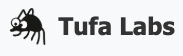

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

This candidate keeps Tufa's solver policy minimal, swaps the analyzer to the public
Qwen3.8-27B-FP8 snapshot with xhigh reasoning, and adds an isolated host checkpoint after
eight actions from one batched request. It verifies and copies the attached TAAF source to
`/kaggle/working` before patching; a source or model-provenance mismatch fails closed.

It installs the ARC runtime from the competition wheelhouse, makes the verified writable
snapshot importable, runs its solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import hashlib
import json
import math
import os
import pickle
import platform
import shutil
import subprocess
import sys
import sysconfig
import time
import zlib
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

SUBMISSION_VARIANT = "taaf-qwen38-xhigh-checkpoint8"
SOURCE_DATASET_REF = "jeroencottaar/taaf-kaggle-source-share"
WHEELHOUSE_DATASET_REF = "driessmit1/arc3-vllm-h100-wheelhouse-v3"
MODEL_DATASET_REF = "jakobbrggen/qwen3-8-27b-fp8-hf-snapshot"
EXPECTED_DATASET_VERSIONS = {
    SOURCE_DATASET_REF: 4,
    WHEELHOUSE_DATASET_REF: 1,
    MODEL_DATASET_REF: 1,
}
MODEL_HF_REF = "Qwen/Qwen3.8-27B-FP8"
MODEL_HF_REVISION = "017b9c7af6b5689d5dd426a76e0bc077eb5ca20a"
SERVED_MODEL_NAME = "Qwen/Qwen3.8-27B-FP8"
REASONING_EFFORT = "xhigh"
BATCH_CHECKPOINT_LIMIT = 8
CANDIDATE_SOLVER_DEFAULTS = {
    "concurrency": 28,
    "analyzer_timeout": 900.0,
    "max_runtime_s_per_game": 7920.0,
}
EXPECTED_DEPLOYMENT_MAX_RUNTIME_S = 32400.0
GRACEFUL_SHUTDOWN_RESERVE_S = 1800.0

TAAF_OFFLINE_GAMES_ENV = "TAAF_OFFLINE_GAMES"
TAAF_OFFLINE_MAX_GAMES_ENV = "TAAF_OFFLINE_MAX_GAMES"
TAAF_SOLVER_ENV_OVERRIDES = (
    ("TAAF_BENCHMARK_CONCURRENCY", "concurrency", "int"),
    ("TAAF_ANALYZER_TIMEOUT", "analyzer_timeout", "float"),
    ("TAAF_MAX_ACTIONS_PER_GAME", "max_actions_per_game", "int"),
    ("TAAF_MAX_RUNTIME_S_PER_GAME", "max_runtime_s_per_game", "float"),
)
RUN_MANIFEST_FILENAME = "taaf_run_manifest.json"
RUN_SUMMARY_FILENAME = "taaf_run_summary.txt"
SUBMISSION_HEALTH_FILENAME = "taaf_submission_health.json"
SAFE_MANIFEST_ENV_VARS = (
    "KAGGLE_IS_COMPETITION_RERUN",
    "TAAF_RUN_AS_SUBMISSION",
    "TAAF_MINIMAL_DIAGNOSTICS",
    "ONLY_RESET_LEVELS",
    TAAF_OFFLINE_GAMES_ENV,
    TAAF_OFFLINE_MAX_GAMES_ENV,
    "TAAF_BENCHMARK_CONCURRENCY",
    "TAAF_ANALYZER_TIMEOUT",
    "TAAF_MAX_ACTIONS_PER_GAME",
    "TAAF_MAX_RUNTIME_S_PER_GAME",
)


def _env_raw(name: str) -> str | None:
    if name not in os.environ:
        return None
    raw = os.environ[name].strip()
    if not raw:
        raise RuntimeError(f"{name} is set but empty.")
    return raw


def _env_optional_int(name: str, *, minimum: int | None = None) -> int | None:
    raw = _env_raw(name)
    if raw is None:
        return None
    try:
        value = int(raw)
    except ValueError as exc:
        raise RuntimeError(f"{name} must be an integer, got {raw!r}.") from exc
    if minimum is not None and value < minimum:
        raise RuntimeError(f"{name} must be >= {minimum}, got {value}.")
    return value


def _env_optional_float(name: str, *, greater_than: float | None = None) -> float | None:
    raw = _env_raw(name)
    if raw is None:
        return None
    try:
        value = float(raw)
    except ValueError as exc:
        raise RuntimeError(f"{name} must be a float, got {raw!r}.") from exc
    if not math.isfinite(value):
        raise RuntimeError(f"{name} must be finite, got {raw!r}.")
    if greater_than is not None and value <= greater_than:
        raise RuntimeError(f"{name} must be > {greater_than}, got {value}.")
    return value


def _env_offline_game_ids() -> list[str] | None:
    raw = _env_raw(TAAF_OFFLINE_GAMES_ENV)
    if raw is None:
        return None
    game_ids = [part for part in raw.replace(",", " ").split() if part]
    if not game_ids:
        raise RuntimeError(f"{TAAF_OFFLINE_GAMES_ENV} must include at least one game id.")
    return game_ids


def _apply_solver_env_overrides(bm) -> None:
    solver = getattr(bm, "solver", None)
    applied = []
    for env_name, attr_name, value_type in TAAF_SOLVER_ENV_OVERRIDES:
        if value_type == "int":
            value = _env_optional_int(env_name, minimum=1)
        elif value_type == "float":
            value = _env_optional_float(env_name, greater_than=0.0)
        else:
            raise RuntimeError(f"Unsupported override type for {env_name}: {value_type!r}.")
        if value is None:
            continue
        if solver is None:
            raise RuntimeError(f"{env_name} is set but bm.solver is not available.")
        if not hasattr(solver, attr_name):
            raise RuntimeError(f"{env_name} is set but bm.solver has no {attr_name!r} attribute.")
        setattr(solver, attr_name, value)
        applied.append(f"{attr_name}={value!r}")
    if applied:
        print(f"taaf.kaggle: solver overrides: {', '.join(applied)}")


def _apply_candidate_solver_defaults(bm) -> None:
    solver = getattr(bm, "solver", None)
    if solver is None:
        raise RuntimeError("Candidate runtime requires bm.solver.")
    for attr_name, value in CANDIDATE_SOLVER_DEFAULTS.items():
        if not hasattr(solver, attr_name):
            raise RuntimeError(f"Candidate runtime requires bm.solver.{attr_name}.")
        setattr(solver, attr_name, value)
    print("taaf.kaggle: candidate solver defaults = " + json.dumps(CANDIDATE_SOLVER_DEFAULTS, sort_keys=True))


def _manifest_json_value(value):
    if value is None or isinstance(value, (bool, int, float, str)):
        return value
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (list, tuple)):
        return [_manifest_json_value(item) for item in value]
    if isinstance(value, dict):
        return {str(key): _manifest_json_value(item) for key, item in value.items()}
    return type(value).__name__


_MANIFEST_MISSING = object()


def _manifest_get_attr(obj, attr_name: str, default=_MANIFEST_MISSING):
    try:
        return getattr(obj, attr_name)
    except AttributeError:
        return default
    except Exception as exc:
        return f"<unavailable: {type(exc).__name__}>"


def _manifest_maybe_add_attr(info: dict, key: str, obj, attr_name: str) -> None:
    value = _manifest_get_attr(obj, attr_name)
    if value is not _MANIFEST_MISSING:
        info[key] = _manifest_json_value(value)


def _manifest_paths() -> tuple[Path, Path]:
    working_dir = Path(globals().get("WORKING_DIR", "/kaggle/working"))
    return working_dir / RUN_MANIFEST_FILENAME, working_dir / RUN_SUMMARY_FILENAME


def _manifest_solver_info() -> dict:
    bm_obj = globals().get("bm")
    if bm_obj is None:
        return {}
    info = {}
    _manifest_maybe_add_attr(info, "label", bm_obj, "label")
    solver = _manifest_get_attr(bm_obj, "solver", None)
    if solver is not None:
        if "label" not in info:
            _manifest_maybe_add_attr(info, "label", solver, "label")
        for attr_name in ("model", "concurrency", "analyzer_timeout", "max_actions_per_game", "max_runtime_s_per_game"):
            _manifest_maybe_add_attr(info, attr_name, solver, attr_name)
    return info


def _write_run_summary(manifest: dict, summary_path: Path) -> None:
    lines = [
        f"milestone: {manifest['milestone']}",
        f"submission_variant: {manifest['submission_variant']}",
        f"written_utc: {manifest['written_utc']}",
        f"TRUE_SUBMISSION: {manifest['TRUE_SUBMISSION']}",
        f"notebook_start_epoch: {manifest['notebook_start_epoch']}",
    ]
    if "model" in manifest:
        lines.append(f"model: {manifest['model']['served_name']}")
        lines.append(f"reasoning_effort: {manifest['model']['reasoning_effort']}")
    if "BUNDLE_DIR" in manifest:
        lines.append(f"BUNDLE_DIR: {manifest['BUNDLE_DIR']}")
    if "selected_game_count" in manifest:
        lines.append(f"selected_game_count: {manifest['selected_game_count']}")
    runtime = manifest.get("runtime") or {}
    for key in ("deployment_max_runtime_s", "graceful_shutdown_reserve_s", "soft_end_epoch"):
        if key in runtime:
            lines.append(f"runtime.{key}: {runtime[key]}")
    solver = manifest.get("solver") or {}
    for key in ("label", "model", "concurrency", "analyzer_timeout", "max_actions_per_game", "max_runtime_s_per_game"):
        if key in solver:
            lines.append(f"solver.{key}: {solver[key]}")
    offline_ids = manifest.get("offline_selected_game_ids")
    if offline_ids is not None:
        preview = ", ".join(offline_ids[:20])
        if len(offline_ids) > 20:
            preview += f", ... (+{len(offline_ids) - 20} more)"
        lines.append(f"offline_selected_game_ids: {preview}")
    summary_path.write_text("\n".join(lines) + "\n")


def _write_run_manifest(milestone: str, *, outcome: str | None = None, error: BaseException | None = None) -> None:
    manifest_path, summary_path = _manifest_paths()
    manifest_path.parent.mkdir(parents=True, exist_ok=True)
    manifest = {
        "milestone": milestone,
        "submission_variant": SUBMISSION_VARIANT,
        "model": {
            "kaggle_dataset_ref": MODEL_DATASET_REF,
            "huggingface_ref": MODEL_HF_REF,
            "huggingface_revision": MODEL_HF_REVISION,
            "served_name": SERVED_MODEL_NAME,
            "reasoning_effort": REASONING_EFFORT,
        },
        "batch_checkpoint_limit": BATCH_CHECKPOINT_LIMIT,
        "expected_dataset_versions": EXPECTED_DATASET_VERSIONS,
        "written_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
        "notebook_start_epoch": NOTEBOOK_START_EPOCH,
        "notebook_start_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime(NOTEBOOK_START_EPOCH)),
        "TRUE_SUBMISSION": bool(globals().get("TRUE_SUBMISSION", False)),
        "runtime": {
            "deployment_max_runtime_s": _manifest_json_value(
                getattr(globals().get("target"), "max_runtime_s", EXPECTED_DEPLOYMENT_MAX_RUNTIME_S)
            ),
            "graceful_shutdown_reserve_s": GRACEFUL_SHUTDOWN_RESERVE_S,
            **(
                {"soft_end_epoch": globals()["soft_end"].timestamp()}
                if globals().get("soft_end") is not None
                else {}
            ),
        },
        "python": {
            "executable": sys.executable,
            "version": sys.version,
            "implementation": platform.python_implementation(),
            "platform": platform.platform(),
            "machine": platform.machine(),
        },
        "env": {name: os.environ[name] for name in SAFE_MANIFEST_ENV_VARS if name in os.environ},
    }
    if outcome is not None:
        manifest["outcome"] = outcome
    if error is not None:
        manifest["error"] = {"type": type(error).__name__, "message": str(error)[:2000]}
    if "DATASET_SOURCES" in globals():
        manifest["DATASET_SOURCES"] = list(DATASET_SOURCES)
    if "KERNEL_SOURCES" in globals():
        manifest["KERNEL_SOURCES"] = list(KERNEL_SOURCES)
    if "kaggle_input_paths" in globals():
        manifest["kaggle_input_paths"] = dict(kaggle_input_paths)
    if "SOURCE_BUNDLE_DIR" in globals():
        manifest["SOURCE_BUNDLE_DIR"] = str(SOURCE_BUNDLE_DIR)
    if "BUNDLE_DIR" in globals():
        manifest["BUNDLE_DIR"] = str(BUNDLE_DIR)
    if "BUNDLE_PATCH_STATUS" in globals():
        manifest["bundle_patch"] = _manifest_json_value(BUNDLE_PATCH_STATUS)
    if "MODEL_SNAPSHOT_STATUS" in globals():
        manifest["model_snapshot"] = _manifest_json_value(MODEL_SNAPSHOT_STATUS)
    if "WHEELHOUSE_STATUS" in globals():
        manifest["wheelhouse"] = _manifest_json_value(WHEELHOUSE_STATUS)
    solver_info = _manifest_solver_info()
    if solver_info:
        manifest["solver"] = solver_info
    bm_obj = globals().get("bm")
    games = getattr(bm_obj, "games", None) if bm_obj is not None else None
    if games is not None:
        try:
            manifest["selected_game_count"] = len(games)
        except TypeError:
            pass
    offline_ids = globals().get("OFFLINE_SELECTED_GAME_IDS")
    if offline_ids is not None and not manifest["TRUE_SUBMISSION"]:
        manifest["offline_selected_game_ids"] = list(offline_ids)
    manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n")
    _write_run_summary(manifest, summary_path)
    print(f"taaf.kaggle: wrote run manifest = {manifest_path}")


def _write_submission_health_summary() -> None:
    if not TRUE_SUBMISSION:
        raise RuntimeError("Submission health summary is only valid in a competition rerun.")
    game_runs = list(getattr(bm, "game_runs", ()) or ())
    selected_game_count = len(getattr(bm, "games", ()) or ())
    problem_count = 0
    for run in game_runs:
        state = getattr(run, "state", None)
        score = getattr(run, "final_score", None)
        solver_note = getattr(run, "solver_note", None)
        score_is_finite = isinstance(score, (int, float)) and not isinstance(score, bool) and math.isfinite(score)
        has_error_note = isinstance(solver_note, str) and solver_note.lower().startswith("error:")
        if state not in {"won", "gave_up"} or not score_is_finite or has_error_note:
            problem_count += 1
    summary = {
        "schema_version": 1,
        "submission_variant": SUBMISSION_VARIANT,
        "n_passes": getattr(bm, "n_passes", None),
        "selected_game_count": selected_game_count,
        "game_run_count": len(game_runs),
        "clean_game_run_count": len(game_runs) - problem_count,
        "problem_game_run_count": problem_count,
        "all_game_runs_completed_cleanly": bool(game_runs) and problem_count == 0,
        "written_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    }
    output_path = WORKING_DIR / SUBMISSION_HEALTH_FILENAME
    temporary_path = output_path.with_suffix(output_path.suffix + ".tmp")
    temporary_path.write_text(json.dumps(summary, indent=2, sort_keys=True) + "\n")
    temporary_path.replace(output_path)
    print(f"taaf.kaggle: wrote compact submission health = {output_path}")


# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")
_write_run_manifest("initial_env_setup")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Verify and prepare the candidate bundle

Find the uploaded TAAF source dataset, verify its exact source hashes, copy it to the writable
working directory, apply checkpoint-8 and Qwen3.8/xhigh substitutions, and validate the
attached model metadata and shard inventory before any source import or unpickling.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = [SOURCE_DATASET_REF, WHEELHOUSE_DATASET_REF, MODEL_DATASET_REF]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
PATCHED_BUNDLE_NAME = "taaf-qwen38-checkpoint8-bundle"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"
EXPECTED_SOURCE_SHA256 = {
    "benchmark_initial.pkl": "7f619ac0831bfc4d138365681fc46de2f7107b54e2d62bbb3194b65d9aec1d67",
    "deploy_target.pkl": "f0dc4b59f390862326b0e40a6ff0f8910d9e6487ae244efb1ae9ab495f79ba19",
    "git_status.txt": "ae9637bab0ed488c0ce3d9db93810c7d2b6759db665791429e7a3befe7143f3a",
    "preamble.txt": "3aefbd3aa7d3a1c5c610b42d13476de509e06834b029f5c88eb6c0980081d6ea",
    "setup_commands.json": "650c2cfe94b972c38883861a2c648e4e32f35d7eefb6af43afaa5b844d0a6bf6",
    "src/ARC3-Inference/inference/framework/solver.py": "65ddfcdbe8c24fdc31246ff018b51469827b21c38995243a36a818adbed33370",
    "src/ARC3-Inference/inference/agent/tool_agent.py": "535ee88b81b262fa5aedb785466ade9f3183a6417656fb6733427242baac7c9d",
    "src/ARC3-Inference/inference/agent/action_names.py": "d359c22dd9f3925ed54cb05a60640e8aa1121c226a068b4736e8dfad46d2d115",
    "taaf-kaggle-bundle.json": "52f844965b2b80de6e6ef759dfc9ffa3258f42407e0ed1788ec28ff250a7a8cb",
    "teardown_commands.json": "25d8cb3f3217baaaf5d671f5f6bc1a1e7e52dc14af2c8676fb1e565d9f36c73c",
}
EXPECTED_PATCHED_SHA256 = {
    **EXPECTED_SOURCE_SHA256,
    "setup_commands.json": "b1ad5e9669c4e66aa79ebaecf8b070f0462fce4b607077849a69f39ace6efec6",
    "src/ARC3-Inference/inference/framework/solver.py": "305bd8883086eea3be572403c8d44b694e717955aa59cb434774d72ee7ca6c59",
    "src/ARC3-Inference/inference/agent/tool_agent.py": "0dc10f16e8aa4c88ce003c0a6d48cfdf8b07a3b6c117f64e3b6ef0a155618bb9",
}
EXPECTED_MODEL_METADATA_SHA256 = {
    "chat_template.jinja": "c3cf9e34abf4f9e36c2d72165aa9c132d3e2a725b6c2586aaa3a8af9d7a81041",
    "config.json": "74227dd615bf1ea975aa676bdf355a0379858c12f394b5365cd9dfa5fc2c70bc",
    "crc32.txt": "5ccb0f7436ae756484561fe915780509845f903ea1780dbe9b0a3a7a0dd095ac",
    "generation_config.json": "e70c136c1b78ddc1fb0905bac8e733a4dc448d4f852a5dd75143fffc70be550e",
    "tokenizer_config.json": "b11349aafa7cdc6a320767cf7ceb29ed82f7eda5d65e8e0819e76f0ce947bf27",
    "model.safetensors.index.json": "f0838c766951bdfe76d6afbdb2771a8f67aaa2231dedb3d33cebd817729843a2",
}
# Dataset version 1 contains a stale crc32.txt for these three metadata files. The
# mounted files are byte-identical to the immutable Hugging Face revision pinned above.
EXPECTED_MODEL_CRC32_CORRECTIONS = {
    "chat_template.jinja": {"manifest": "cf59f3ab", "actual": "367cbad5"},
    "generation_config.json": {"manifest": "ac8d98f1", "actual": "58cd7d0f"},
    "tokenizer_config.json": {"manifest": "7adf2118", "actual": "f3d608c1"},
}
EXPECTED_BUNDLE_FILE_COUNT = 73
EXPECTED_SOURCE_TREE_SHA256 = "f8554ee8224e0701266459a9322ce4553e94f9239539196fee27992db4c7e11f"
EXPECTED_PATCHED_TREE_SHA256 = "686d07fe0d69cd73942f14de4c4f0c165b1956009d1eb9bdd439dd4b7b9e5c30"
EXPECTED_WHEELHOUSE_METADATA_SHA256 = {
    "SHA256SUMS": "44029b360a9c0073e4b0add10703fc3386dc06bf1314f5913a0dad9564144cbb",
    "requirements.lock": "59d4e7231d8a94cf12f5b8289dd38a200243e725f7f3a68365022cceb2167f88",
    "wheelhouse-manifest.json": "bc016164d15664c52911fcd11f4e26e72a483e248f3cc9b59ae02b3fce09cc6a",
}
EXPECTED_WHEELHOUSE_FILE_COUNT = 180
EXPECTED_MODEL_FILE_COUNT = 80


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


def _validate_bundle_dir(bundle_dir: Path) -> None:
    required_paths = [
        ("setup_commands.json", "file"),
        ("teardown_commands.json", "file"),
        ("deploy_target.pkl", "file"),
        ("benchmark_initial.pkl", "file"),
        ("preamble.txt", "file"),
        ("git_status.txt", "file"),
        ("src", "dir"),
    ]
    missing = []
    for relative_path, path_type in required_paths:
        path = bundle_dir / relative_path
        exists = path.is_dir() if path_type == "dir" else path.is_file()
        if not exists:
            missing.append(f"{relative_path}/" if path_type == "dir" else relative_path)
    if missing:
        raise RuntimeError("TAAF source bundle is missing required paths: " + ", ".join(missing))


def _sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def _crc32(path: Path) -> str:
    checksum = 0
    with path.open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            checksum = zlib.crc32(block, checksum)
    return f"{checksum & 0xFFFFFFFF:08x}"


def _bundle_tree_sha256(root: Path) -> tuple[str, int]:
    digest = hashlib.sha256()
    files = sorted(path for path in root.rglob("*") if path.is_file())
    for path in files:
        if path.is_symlink():
            raise RuntimeError(f"Bundle contains an unsupported symlink: {path}")
        digest.update(path.relative_to(root).as_posix().encode("utf-8"))
        digest.update(b"\0")
        with path.open("rb") as file:
            for block in iter(lambda: file.read(1024 * 1024), b""):
                digest.update(block)
        digest.update(b"\0")
    return digest.hexdigest(), len(files)


def _verify_bundle_tree(root: Path, expected_hash: str, *, stage: str) -> dict:
    actual_hash, file_count = _bundle_tree_sha256(root)
    if file_count != EXPECTED_BUNDLE_FILE_COUNT or actual_hash != expected_hash:
        raise RuntimeError(
            f"{stage} tree verification failed: expected {EXPECTED_BUNDLE_FILE_COUNT} files "
            f"and {expected_hash}, got {file_count} files and {actual_hash}."
        )
    return {"sha256": actual_hash, "file_count": file_count}


def _verify_hashes(root: Path, expected: dict[str, str], *, stage: str) -> dict[str, str]:
    actual = {}
    mismatches = []
    for relative_path, expected_hash in expected.items():
        path = root / relative_path
        if not path.is_file():
            mismatches.append(f"{relative_path}: missing")
            continue
        actual_hash = _sha256(path)
        actual[relative_path] = actual_hash
        if actual_hash != expected_hash:
            mismatches.append(f"{relative_path}: expected {expected_hash}, got {actual_hash}")
    if mismatches:
        raise RuntimeError(f"{stage} hash verification failed: " + "; ".join(mismatches))
    return actual


def _validate_wheelhouse(wheelhouse_dir: Path) -> dict:
    metadata_hashes = _verify_hashes(
        wheelhouse_dir, EXPECTED_WHEELHOUSE_METADATA_SHA256, stage="vLLM wheelhouse metadata"
    )
    sums_path = wheelhouse_dir / "SHA256SUMS"
    expected_files = {}
    for line in sums_path.read_text(encoding="utf-8").splitlines():
        parts = line.split(None, 1)
        if len(parts) != 2 or Path(parts[1].strip()).name != parts[1].strip():
            raise RuntimeError(f"Invalid vLLM wheelhouse SHA256SUMS line: {line!r}")
        expected_files[parts[1].strip()] = parts[0].lower()
    if len(expected_files) != 179:
        raise RuntimeError(f"Expected 179 vLLM wheelhouse checksum entries, found {len(expected_files)}.")
    # The published checksum set includes generation-time dataset-metadata.json, while the
    # version-1 Kaggle dataset exposes the 178 payload files plus these two manifests.
    expected_files.pop("dataset-metadata.json", None)
    expected_names = set(expected_files) | {"SHA256SUMS", "wheelhouse-manifest.json"}
    actual_names = {path.name for path in wheelhouse_dir.iterdir() if path.is_file()}
    unexpected_dirs = [path.name for path in wheelhouse_dir.iterdir() if path.is_dir()]
    if unexpected_dirs or len(actual_names) != EXPECTED_WHEELHOUSE_FILE_COUNT or actual_names != expected_names:
        missing = sorted(expected_names - actual_names)
        extra = sorted(actual_names - expected_names)
        raise RuntimeError(
            "vLLM wheelhouse inventory mismatch: "
            f"expected {EXPECTED_WHEELHOUSE_FILE_COUNT} files, got {len(actual_names)}; "
            f"missing={missing}, extra={extra}, directories={unexpected_dirs}."
        )
    payload_hashes = _verify_hashes(wheelhouse_dir, expected_files, stage="vLLM wheelhouse payload")
    manifest = json.loads((wheelhouse_dir / "wheelhouse-manifest.json").read_text(encoding="utf-8"))
    core_versions = manifest.get("core_versions") or {}
    required_versions = {"vllm": "0.19.0", "torch": "2.10.0", "transformers": "4.57.6"}
    if any(core_versions.get(name) != version for name, version in required_versions.items()):
        raise RuntimeError(f"Unexpected vLLM wheelhouse core versions: {core_versions!r}.")
    return {
        "status": "inventory_and_sha256_verified",
        "file_count": len(actual_names),
        "payload_bytes": sum((wheelhouse_dir / name).stat().st_size for name in expected_files),
        "metadata_sha256": metadata_hashes,
        "payload_sha256_count": len(payload_hashes),
        "core_versions": required_versions,
    }


def _replace_exact(text: str, old: str, new: str, *, label: str) -> str:
    count = text.count(old)
    if count != 1:
        raise RuntimeError(f"Patch anchor {label!r} matched {count} times; expected exactly once.")
    return text.replace(old, new)


def _apply_checkpoint8_patch(bundle_dir: Path) -> None:
    solver_path = bundle_dir / "src/ARC3-Inference/inference/framework/solver.py"
    tool_path = bundle_dir / "src/ARC3-Inference/inference/agent/tool_agent.py"
    solver = solver_path.read_text(encoding="utf-8")
    solver = _replace_exact(
        solver,
        '        for batch_index, action in enumerate(requested_actions, start=1):\n            if self.should_stop():\n',
        '        # Isolated cap-8 ablation on the pristine TAAF harness: execute at most\n'
        '        # eight actions from one action(...) request, then return the settled\n'
        '        # board and the unexecuted suffix to the same Python REPL.\n'
        '        batch_checkpoint_limit = 8\n'
        '        for batch_index, action in enumerate(requested_actions, start=1):\n'
        '            if batch_index > batch_checkpoint_limit:\n'
        '                stop_reason = "batch_checkpoint"\n'
        '                break\n'
        '            if self.should_stop():\n',
        label="solver checkpoint loop",
    )
    solver = _replace_exact(
        solver,
        '        if stop_reason is not None:\n            final_payload["stop_reason"] = stop_reason\n        self.write_viewer_payload()\n',
        '        if stop_reason is not None:\n            final_payload["stop_reason"] = stop_reason\n'
        '        if stop_reason == "batch_checkpoint":\n'
        '            final_payload["batch_checkpoint_limit"] = batch_checkpoint_limit\n'
        '            final_payload["unexecuted_actions"] = requested_displays[len(executed_payloads):]\n'
        '        self.write_viewer_payload()\n',
        label="solver checkpoint payload",
    )
    solver_path.write_text(solver, encoding="utf-8")

    tool = tool_path.read_text(encoding="utf-8")
    tool = _replace_exact(
        tool,
        '        if payload.get("stop_detail"):\n            compact["stop_detail"] = payload.get("stop_detail")\n        for timing_key in ("run_elapsed_seconds", "time_remaining_seconds"):\n',
        '        if payload.get("stop_detail"):\n            compact["stop_detail"] = payload.get("stop_detail")\n'
        '        for checkpoint_key in ("batch_checkpoint_limit", "unexecuted_actions"):\n'
        '            if payload.get(checkpoint_key) is not None:\n'
        '                compact[checkpoint_key] = payload.get(checkpoint_key)\n'
        '        if compact.get("stop_reason") == "batch_checkpoint":\n'
        '            compact["note"] = (\n'
        '                f"Host checkpoint after {compact.get(\'batch_checkpoint_limit\')} actions. "\n'
        '                "Re-ground on the settled board before deciding whether the returned "\n'
        '                "unexecuted suffix is still valid."\n'
        '            )\n'
        '        for timing_key in ("run_elapsed_seconds", "time_remaining_seconds"):\n',
        label="tool checkpoint metadata",
    )
    tool_path.write_text(tool, encoding="utf-8")


def _patch_setup_commands(bundle_dir: Path) -> None:
    setup_path = bundle_dir / "setup_commands.json"
    commands = json.loads(setup_path.read_text(encoding="utf-8"))
    if not isinstance(commands, list) or len(commands) != 1 or not isinstance(commands[0], str):
        raise RuntimeError("Expected exactly one string command in setup_commands.json.")
    command = commands[0]
    substitutions = (
        ("MODEL_OWNER = 'driessmit1'", "MODEL_OWNER = 'jakobbrggen'", "model owner"),
        ("MODEL_SLUG = 'vrfai-qwen3-6-27b-fp8-hf-snapshot'", "MODEL_SLUG = 'qwen3-8-27b-fp8-hf-snapshot'", "model slug"),
        ("SERVED_MODEL_NAME = 'vrfai/Qwen3.6-27B-FP8'", "SERVED_MODEL_NAME = 'Qwen/Qwen3.8-27B-FP8'", "served model name"),
        ('{\"preserve_thinking\": true}', '{\"preserve_thinking\": true, \"reasoning_effort\": \"xhigh\"}', "xhigh reasoning"),
    )
    for old, new, label in substitutions:
        command = _replace_exact(command, old, new, label=label)
    setup_path.write_text(json.dumps([command], indent=2) + "\n", encoding="utf-8")


def _prepare_patched_bundle(source_bundle_dir: Path) -> tuple[Path, dict]:
    source_tree = _verify_bundle_tree(source_bundle_dir, EXPECTED_SOURCE_TREE_SHA256, stage="TAAF source")
    source_hashes = _verify_hashes(source_bundle_dir, EXPECTED_SOURCE_SHA256, stage="TAAF source")
    patched_bundle_dir = WORKING_DIR / PATCHED_BUNDLE_NAME
    if patched_bundle_dir.exists():
        patched_tree = _verify_bundle_tree(patched_bundle_dir, EXPECTED_PATCHED_TREE_SHA256, stage="existing patched TAAF")
        patched_hashes = _verify_hashes(patched_bundle_dir, EXPECTED_PATCHED_SHA256, stage="existing patched TAAF")
        return patched_bundle_dir, {
            "status": "verified_existing_copy",
            "source_tree": source_tree,
            "patched_tree": patched_tree,
            "source_hashes": source_hashes,
            "patched_hashes": patched_hashes,
        }
    shutil.copytree(source_bundle_dir, patched_bundle_dir)
    _apply_checkpoint8_patch(patched_bundle_dir)
    _patch_setup_commands(patched_bundle_dir)
    patched_tree = _verify_bundle_tree(patched_bundle_dir, EXPECTED_PATCHED_TREE_SHA256, stage="patched TAAF")
    patched_hashes = _verify_hashes(patched_bundle_dir, EXPECTED_PATCHED_SHA256, stage="patched TAAF")
    return patched_bundle_dir, {
        "status": "verified_and_applied",
        "source_tree": source_tree,
        "patched_tree": patched_tree,
        "source_hashes": source_hashes,
        "patched_hashes": patched_hashes,
    }


def _validate_model_snapshot(model_dir: Path) -> dict:
    if not (model_dir / "config.json").is_file():
        nested = [path.parent for path in model_dir.rglob("config.json") if path.is_file()]
        if len(nested) == 1:
            model_dir = nested[0]
        elif nested:
            raise RuntimeError("Qwen3.8 dataset contains multiple candidate snapshot roots: " + ", ".join(str(path) for path in nested))
    config_path = model_dir / "config.json"
    tokenizer_config_path = model_dir / "tokenizer_config.json"
    index_path = model_dir / "model.safetensors.index.json"
    crc32_path = model_dir / "crc32.txt"
    required = [config_path, tokenizer_config_path, index_path, crc32_path]
    missing = [str(path) for path in required if not path.is_file()]
    if missing:
        raise RuntimeError("Qwen3.8 snapshot is missing metadata files: " + ", ".join(missing))
    metadata_hashes = _verify_hashes(model_dir, EXPECTED_MODEL_METADATA_SHA256, stage="Qwen3.8 metadata")
    config = json.loads(config_path.read_text(encoding="utf-8"))
    tokenizer_config = json.loads(tokenizer_config_path.read_text(encoding="utf-8"))
    index = json.loads(index_path.read_text(encoding="utf-8"))
    if config.get("model_type") != "qwen3_5":
        raise RuntimeError(f"Unexpected Qwen3.8 model_type: {config.get('model_type')!r}.")
    if config.get("architectures") != ["Qwen3_5ForConditionalGeneration"]:
        raise RuntimeError(f"Unexpected Qwen3.8 architectures: {config.get('architectures')!r}.")
    if (config.get("quantization_config") or {}).get("quant_method") != "fp8":
        raise RuntimeError("Qwen3.8 snapshot is not identified as FP8.")
    chat_template = str(tokenizer_config.get("chat_template") or "")
    for anchor in ("reasoning_effort|default('xhigh')", "preserve_thinking"):
        if anchor not in chat_template:
            raise RuntimeError(f"Qwen3.8 chat template is missing {anchor!r}.")
    shard_names = sorted({str(name) for name in (index.get("weight_map") or {}).values()})
    if len(shard_names) != 66:
        raise RuntimeError(f"Expected 66 Qwen3.8 weight shards, found {len(shard_names)}.")
    missing_shards = [
        name for name in shard_names
        if not (model_dir / name).is_file() or (model_dir / name).stat().st_size <= 0
    ]
    if missing_shards:
        raise RuntimeError("Qwen3.8 snapshot is missing weight shards: " + ", ".join(missing_shards))
    expected_crc32 = {}
    for line in crc32_path.read_text(encoding="utf-8").splitlines():
        parts = line.split(None, 1)
        if len(parts) == 2:
            expected_crc32[parts[1].strip()] = parts[0].lower()
    if len(expected_crc32) != 77:
        raise RuntimeError(f"Expected 77 Qwen3.8 CRC32 entries, found {len(expected_crc32)}.")
    for name, correction in EXPECTED_MODEL_CRC32_CORRECTIONS.items():
        manifest_crc32 = expected_crc32.get(name)
        if manifest_crc32 != correction["manifest"]:
            raise RuntimeError(
                f"Qwen3.8 CRC32 correction precondition failed for {name}: "
                f"expected stale value {correction['manifest']}, got {manifest_crc32!r}."
            )
        expected_crc32[name] = correction["actual"]
    missing_crc_entries = [name for name in shard_names if name not in expected_crc32]
    if missing_crc_entries:
        raise RuntimeError("Qwen3.8 CRC32 manifest is missing weight shards: " + ", ".join(missing_crc_entries))
    expected_names = set(expected_crc32) | {"LICENSE", "README.md", "crc32.txt"}
    actual_names = {path.name for path in model_dir.iterdir() if path.is_file()}
    unexpected_dirs = [path.name for path in model_dir.iterdir() if path.is_dir()]
    if unexpected_dirs or len(actual_names) != EXPECTED_MODEL_FILE_COUNT or actual_names != expected_names:
        missing = sorted(expected_names - actual_names)
        extra = sorted(actual_names - expected_names)
        raise RuntimeError(
            "Qwen3.8 snapshot inventory mismatch: "
            f"expected {EXPECTED_MODEL_FILE_COUNT} files, got {len(actual_names)}; "
            f"missing={missing}, extra={extra}, directories={unexpected_dirs}."
        )
    crc_mismatches = []
    for name in sorted(expected_crc32):
        actual_crc32 = _crc32(model_dir / name)
        if actual_crc32 != expected_crc32[name]:
            crc_mismatches.append(f"{name}: expected {expected_crc32[name]}, got {actual_crc32}")
    if crc_mismatches:
        raise RuntimeError("Qwen3.8 payload CRC32 verification failed: " + "; ".join(crc_mismatches))
    return {
        "status": "inventory_and_crc32_verified",
        "resolved_path": str(model_dir),
        "model_type": config["model_type"],
        "architecture": config["architectures"][0],
        "quant_method": config["quantization_config"]["quant_method"],
        "weight_shard_count": len(shard_names),
        "weight_bytes": sum((model_dir / name).stat().st_size for name in shard_names),
        "file_count": len(actual_names),
        "crc32_count": len(expected_crc32),
        "crc32_correction_count": len(EXPECTED_MODEL_CRC32_CORRECTIONS),
        "metadata_sha256": metadata_hashes,
    }


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


SOURCE_BUNDLE_DIR = _find_bundle_dir()
_validate_bundle_dir(SOURCE_BUNDLE_DIR)
print(f"taaf.kaggle: read-only source bundle = {SOURCE_BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
missing_attached_inputs = []
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = SOURCE_BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
    if i != 0 and resolved is None:
        missing_attached_inputs.append(f"{ref}: expected one of {', '.join(str(c) for c in candidates)}")
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    resolved = _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
    if resolved is None:
        missing_attached_inputs.append(f"{ref}: expected one of {', '.join(str(c) for c in candidates)}")
if missing_attached_inputs:
    raise RuntimeError("Required Kaggle inputs are missing: " + "; ".join(missing_attached_inputs))

WHEELHOUSE_STATUS = _validate_wheelhouse(Path(kaggle_input_paths[WHEELHOUSE_DATASET_REF]))
MODEL_SNAPSHOT_STATUS = _validate_model_snapshot(Path(kaggle_input_paths[MODEL_DATASET_REF]))
kaggle_input_paths[MODEL_DATASET_REF] = MODEL_SNAPSHOT_STATUS["resolved_path"]
BUNDLE_DIR, BUNDLE_PATCH_STATUS = _prepare_patched_bundle(SOURCE_BUNDLE_DIR)
_validate_bundle_dir(BUNDLE_DIR)
kaggle_input_paths[SOURCE_DATASET_REF] = str(BUNDLE_DIR)
print(f"taaf.kaggle: verified patched bundle = {BUNDLE_DIR}")

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")
_write_run_manifest("bundle_input_paths_resolved")

## 4. Import the verified candidate and run solver setup

Put the patched repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION
deployment_max_runtime_s = getattr(target, "max_runtime_s", None)
if (
    isinstance(deployment_max_runtime_s, bool)
    or not isinstance(deployment_max_runtime_s, (int, float))
    or not math.isfinite(deployment_max_runtime_s)
    or float(deployment_max_runtime_s) != EXPECTED_DEPLOYMENT_MAX_RUNTIME_S
):
    raise RuntimeError(
        "Pinned deployment runtime mismatch: expected "
        f"{EXPECTED_DEPLOYMENT_MAX_RUNTIME_S}, got {deployment_max_runtime_s!r}."
    )

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR
_apply_candidate_solver_defaults(bm)
_apply_solver_env_overrides(bm)
_write_run_manifest("benchmark_loaded_candidate_defaults_applied")

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# Make one-off changes to `bm`, `bm.games`, or `bm.solver` here before the run starts.
# Example:
# bm.label = f"{bm.label}-debug"

## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
_OFFLINE_GAME_IDS_BY_OBJECT: dict[int, str] = {}
OFFLINE_SELECTED_GAME_IDS: list[str] | None = None


# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    games = []
    for game_id in game_ids:
        game = taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec)
        _OFFLINE_GAME_IDS_BY_OBJECT[id(game)] = game_id
        games.append(game)
    return games


def _offline_game_id(game) -> str:
    mapped_game_id = _OFFLINE_GAME_IDS_BY_OBJECT.get(id(game))
    if mapped_game_id:
        return mapped_game_id
    for attr_name in ("env_name", "game_id", "game_name", "environment_id", "id", "name"):
        value = getattr(game, attr_name, None)
        if value and not callable(value):
            return str(value)
    raise RuntimeError(f"Could not determine offline game id for {type(game).__name__}.")


def _filter_offline_games(games: list) -> list:
    requested_ids = _env_offline_game_ids()
    if requested_ids is None:
        return games
    selected = []
    available_ids = []
    for game in games:
        game_id = _offline_game_id(game)
        available_ids.append(game_id)
        if any(game_id == requested_id or game_id.startswith(requested_id) for requested_id in requested_ids):
            selected.append(game)
    if not selected:
        preview = ", ".join(available_ids[:20])
        raise RuntimeError(
            f"{TAAF_OFFLINE_GAMES_ENV}={os.environ.get(TAAF_OFFLINE_GAMES_ENV)!r} matched zero offline games. "
            f"Available game ids start with: {preview}"
        )
    print(f"taaf.kaggle: {TAAF_OFFLINE_GAMES_ENV} kept {len(selected)} of {len(games)} offline games")
    return selected


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    offline_games = _filter_offline_games(_offline_games(competition_env_files))
    max_offline_games = _env_optional_int(TAAF_OFFLINE_MAX_GAMES_ENV, minimum=1)
    if max_offline_games is not None:
        offline_games = offline_games[:max_offline_games]
        print(f"taaf.kaggle: {TAAF_OFFLINE_MAX_GAMES_ENV} kept {len(offline_games)} offline games")
    OFFLINE_SELECTED_GAME_IDS = [_offline_game_id(game) for game in offline_games]
    bm.games = offline_games

bm.n_passes = 1
bm.game_weights = None
_write_run_manifest("game_list_selected")

# Stop before the pinned nine-hour wall-clock budget in every mode. Normal scored-shape
# runs finish earlier; this guard preserves teardown and the scorecard if timing drifts.
soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(
    seconds=EXPECTED_DEPLOYMENT_MAX_RUNTIME_S - GRACEFUL_SHUTDOWN_RESERVE_S
)

# Play the benchmark; persist an explicit terminal outcome and always run teardown.
_write_run_manifest("benchmark_running", outcome="running")
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if TRUE_SUBMISSION:
        # Preserve TAAF's hidden-run diagnostics boundary: emit only aggregate health counts,
        # never game ids, scores, actions, frames, transcripts, or a full benchmark snapshot.
        _write_submission_health_summary()
    else:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
except BaseException as exc:
    _write_run_manifest("benchmark_failed", outcome="failed", error=exc)
    raise
else:
    _write_run_manifest("benchmark_completed", outcome="completed")
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")